# Market & AI Pulse: Key Findings

**Sections:**
1. AI basket vs. S&P 500: full-period return
2. Does AI-sector search attention move before or after the stock moves?
3. AI basket trading-volume concentration
4. Sector return sensitivity to interest-rate moves
5. Realized volatility trend

## Setup

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from IPython.display import Markdown, display

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# --- config: adjust these to change the analysis without touching logic below ---
DATA_BASE_URL = 'https://pdglenchur-glitch.github.io/market_ai_pulse/data'
TOP_N_SPIKES = 5          # how many biggest attention spikes to event-study
EVENT_WINDOW_DAYS = 10    # trading days before/after each spike to measure
LAG_RANGE = range(-10, 11)  # lags (trading days) to test in the correlation scan

def fetch(table_name):
    url = f'{DATA_BASE_URL}/{table_name}.json'
    return pd.DataFrame(requests.get(url, timeout=30).json())

market = fetch('market_daily')
sector = fetch('sector_rotation')
ai_vs_market = fetch('ai_vs_market')
ai_basket_detail = fetch('ai_basket_detail')
attention = fetch('attention_index')
macro = fetch('macro_snapshot')
volatility = fetch('volatility')

print(f"Notebook run at: {datetime.now(timezone.utc).isoformat(timespec='seconds')}")
print(f"Latest market data date: {market['date'].max()}")
print(f"Latest attention data date: {attention['date'].max()}")
print(f"Trading days of AI-basket history: {ai_vs_market['ai_basket_return'].notna().sum()}")

Notebook run at: 2026-07-28T16:22:50+00:00
Latest market data date: 2026-07-28
Latest attention data date: 2026-07-27
Trading days of AI-basket history: 255


## 1. AI basket vs. S&P 500

Compounds each series' daily return over the full available history to get a total cumulative return, then plots the two cumulative-return curves side by side.

In [2]:
avm = ai_vs_market.dropna(subset=['ai_basket_return', 'benchmark_return']).sort_values('date').reset_index(drop=True)

avm['ai_cum'] = (1 + avm['ai_basket_return']).cumprod() - 1
avm['bench_cum'] = (1 + avm['benchmark_return']).cumprod() - 1

ai_total = avm['ai_cum'].iloc[-1]
bench_total = avm['bench_cum'].iloc[-1]
spread = ai_total - bench_total

print(f"AI basket cumulative return:  {ai_total*100:+.2f}%")
print(f"S&P 500 cumulative return:    {bench_total*100:+.2f}%")
print(f"Spread:                       {spread*100:+.2f} points")
print(f"Window: {avm['date'].iloc[0]} -> {avm['date'].iloc[-1]}")

AI basket cumulative return:  +33.49%
S&P 500 cumulative return:    +17.92%
Spread:                       +15.57 points
Window: 2025-07-23 -> 2026-07-28


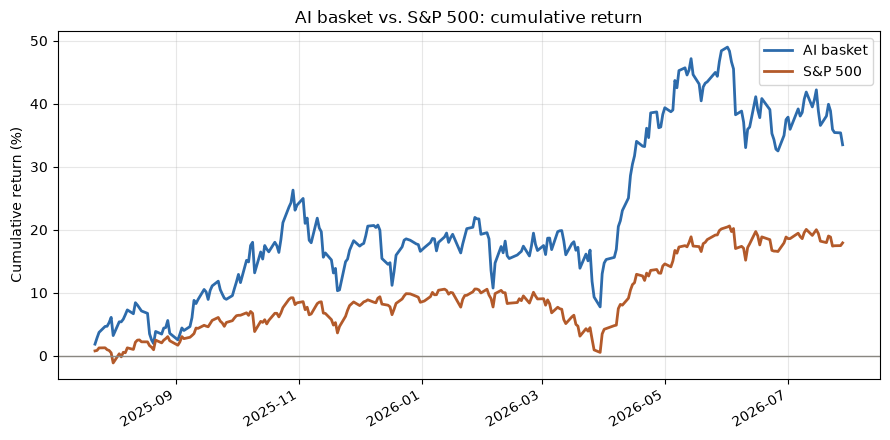

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
dates = pd.to_datetime(avm['date'])
ax.plot(dates, avm['ai_cum']*100, label='AI basket', color='#2d6bab', linewidth=2)
ax.plot(dates, avm['bench_cum']*100, label='S&P 500', color='#b35a2a', linewidth=2)
ax.axhline(0, color='#898781', linewidth=1)
ax.set_ylabel('Cumulative return (%)')
ax.set_title('AI basket vs. S&P 500: cumulative return')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [4]:
direction = "outperformed" if spread > 0 else "underperformed"
magnitude = "a wide" if abs(spread * 100) >= 5 else "a narrow"

display(Markdown(
    f"**Key finding:** the AI basket has {direction} the S&P 500 by {magnitude} margin over this window, "
    f"{spread*100:+.1f} points ({ai_total*100:+.1f}% vs. {bench_total*100:+.1f}%). "
    + (
        "That gap is compounded over the full period rather than driven by any single volatile week, "
        "so it reads as a real, sustained premium for AI exposure."
        if spread > 0 else
        "The AI trade has given back its edge over the broader market during this window."
    )
))

**Key finding:** the AI basket has outperformed the S&P 500 by a wide margin over this window, +15.6 points (+33.5% vs. +17.9%). That gap is compounded over the full period rather than driven by any single volatile week, so it reads as a real, sustained premium for AI exposure.

In [5]:
if spread > 0:
    insight_text = (
        "For an investor weighing whether to stay overweight AI relative to a broad index fund, this spread is the "
        "most direct evidence available that the position is still paying off. The action this supports is holding "
        "it while watching whether the spread keeps widening, which would say conviction is still building, or "
        "starts flattening, which would be the cue to trim back toward index weight before the premium erodes."
    )
else:
    insight_text = (
        "For an investor holding an AI overweight, this is the signal to reassess it. The extra return that would "
        "justify concentrating in AI names rather than simply holding the index isn't showing up over this window, "
        "so continuing to carry that overweight is a bet on the underlying growth story rather than on what the "
        "market is currently pricing in."
    )

display(Markdown(f"**Insight:** {insight_text}"))

**Insight:** For an investor weighing whether to stay overweight AI relative to a broad index fund, this spread is the most direct evidence available that the position is still paying off. The action this supports is holding it while watching whether the spread keeps widening, which would say conviction is still building, or starts flattening, which would be the cue to trim back toward index weight before the premium erodes.

## 2. Does AI-sector search attention move before or after the stock moves?

Public interest (Wikipedia pageviews on "Artificial intelligence," "ChatGPT," and "Large language model") is a plausible leading indicator for AI-stock sentiment, but it could just as easily be a lagging one (people search *because* a stock moved), or unrelated. This section tests it two ways rather than asserting an answer from a single observation.

In [6]:
attn = attention.groupby('date', as_index=False)['views'].sum().sort_values('date').reset_index(drop=True)
attn['views_pct_change'] = attn['views'].pct_change()

top_spikes = attn.dropna(subset=['views_pct_change']).nlargest(TOP_N_SPIKES, 'views_pct_change')
print(f"Top {TOP_N_SPIKES} single-day combined-attention spikes:")
top_spikes[['date', 'views', 'views_pct_change']].assign(
    views_pct_change=lambda d: (d['views_pct_change']*100).round(1)
)

Top 5 single-day combined-attention spikes:


,date,views,views_pct_change
251,2026-03-30,294984,251.80
364,2026-07-21,183346,171.30
119,2025-11-18,357396,114.40
219,2026-02-26,226717,77.40
91,2025-10-21,321071,62.70


### 2a. Day-to-day correlation across the full history

For each lag *k* (trading days), correlates today's attention change with the AI-basket return *k* days away. **k > 0** means attention today correlates with a *future* stock return (attention would be leading). **k < 0** means attention today correlates with a *past* stock return (stock moves would be leading, attention lagging).

In [7]:
merged = attn.merge(ai_vs_market[['date', 'ai_basket_return']], on='date', how='outer').sort_values('date').reset_index(drop=True)
attn_series = merged['views_pct_change'].to_numpy()
ret_series = merged['ai_basket_return'].to_numpy()
n = len(merged)

lag_results = []
for k in LAG_RANGE:
    xs, ys = [], []
    for i in range(n):
        j = i + k
        if 0 <= j < n and not np.isnan(attn_series[i]) and not np.isnan(ret_series[j]):
            xs.append(attn_series[i]); ys.append(ret_series[j])
    corr = np.corrcoef(xs, ys)[0, 1] if len(xs) >= 3 else np.nan
    lag_results.append({'lag': k, 'correlation': corr, 'n_pairs': len(xs)})

lag_df = pd.DataFrame(lag_results)
best = lag_df.loc[lag_df['correlation'].abs().idxmax()]
print(f"Strongest |correlation|: lag={int(best['lag'])}, r={best['correlation']:+.4f}, n={int(best['n_pairs'])}")
# rough 95% no-correlation threshold for reference, ~2/sqrt(n)
threshold = 2 / np.sqrt(lag_df['n_pairs'].mean())
print(f"Approx. 95% no-correlation threshold for this sample size: +/-{threshold:.3f}")
print(f"Note: {len(list(LAG_RANGE))} lags were tested, so a single lag crossing this threshold is expected by chance alone "
      "and is not strong evidence on its own.")
lag_df

Strongest |correlation|: lag=-4, r=-0.1847, n=252
Approx. 95% no-correlation threshold for this sample size: +/-0.126
Note: 21 lags were tested, so a single lag crossing this threshold is expected by chance alone and is not strong evidence on its own.


,lag,correlation,n_pairs
0,-10,-0.09,248
1,-9,0.04,248
2,-8,0.05,248
3,-7,0.13,249
4,-6,0.01,250
5,-5,-0.01,251
6,-4,-0.18,252
7,-3,-0.09,253
8,-2,0.06,253
9,-1,0.13,253


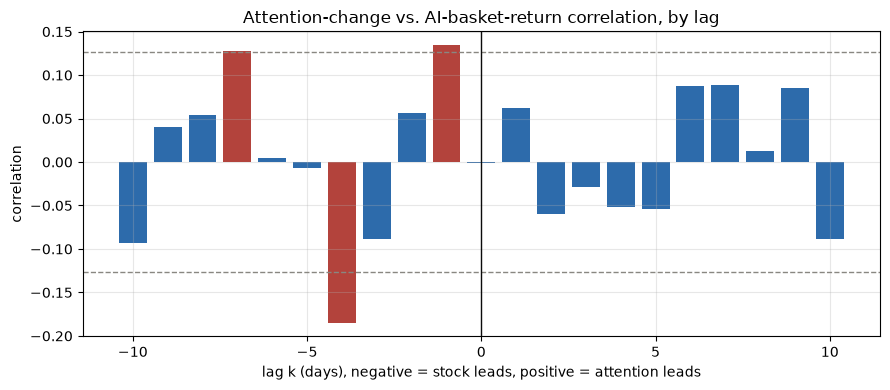

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#b3433c' if abs(c) >= threshold else '#2d6bab' for c in lag_df['correlation']]
ax.bar(lag_df['lag'], lag_df['correlation'], color=colors)
ax.axhline(threshold, color='#898781', linestyle='--', linewidth=1)
ax.axhline(-threshold, color='#898781', linestyle='--', linewidth=1)
ax.axvline(0, color='#0b0b0b', linewidth=1)
ax.set_xlabel('lag k (days), negative = stock leads, positive = attention leads')
ax.set_ylabel('correlation')
ax.set_title('Attention-change vs. AI-basket-return correlation, by lag')
plt.tight_layout()
plt.show()

**Reading this chart:** if attention genuinely led (or lagged) stock moves, we'd expect a cluster of bars on one side of zero to consistently clear the dashed threshold. What we actually see is scattered, roughly random-looking bars on both sides, consistent with noise rather than a real day-to-day relationship.

### 2b. Event study: the biggest attention spikes specifically

Routine day-to-day search chatter showed nothing above. A different, more targeted question: do the *few genuinely large* attention spikes behave differently than routine noise? Compares AI-basket cumulative return in the window before vs. after each of the top spikes.

In [9]:
dates_list = attn['date'].tolist()
date_idx = {d: i for i, d in enumerate(dates_list)}
ret_by_date = ai_vs_market.set_index('date')['ai_basket_return'].to_dict()

def window_return(center_date, start_offset, end_offset):
    ci = date_idx[center_date]
    cum, count = 1.0, 0
    for i in range(ci + start_offset, ci + end_offset + 1):
        if 0 <= i < len(dates_list):
            r = ret_by_date.get(dates_list[i])
            if r is not None and not (isinstance(r, float) and np.isnan(r)):
                cum *= (1 + r); count += 1
    return (cum - 1) * 100, count

event_rows = []
for _, row in top_spikes.iterrows():
    before, n_before = window_return(row['date'], -EVENT_WINDOW_DAYS, -1)
    after, n_after = window_return(row['date'], 1, EVENT_WINDOW_DAYS)
    event_rows.append({
        'spike_date': row['date'], 'spike_size_pct': row['views_pct_change'] * 100,
        'return_before_pct': before, 'n_before': n_before,
        'return_after_pct': after, 'n_after': n_after,
    })
event_df = pd.DataFrame(event_rows)
print(f"Average return before: {event_df['return_before_pct'].mean():+.2f}%")
print(f"Average return after:  {event_df['return_after_pct'].mean():+.2f}%")
event_df.round(2)

Average return before: -0.79%
Average return after:  +3.75%


,spike_date,spike_size_pct,return_before_pct,n_before,return_after_pct,n_after
0,2026-03-30,251.81,-6.73,6,12.69,7
1,2026-07-21,171.34,-2.68,6,-3.25,4
2,2025-11-18,114.44,-2.31,6,4.53,7
3,2026-02-26,77.41,3.49,7,-0.71,6
4,2025-10-21,62.66,4.29,6,5.48,8


**Honest conclusion:** the full-history correlation test found no reliable day-to-day lead-lag relationship: routine search-interest fluctuation doesn't predict or follow routine stock moves. The event study on the small number of genuinely large spikes shows a real gap (return-after minus return-before), but with only a handful of events this is suggestive at best rather than statistically reliable, and is worth re-checking every time this notebook is re-run as more spikes accumulate into the sample.

In [10]:
gap = event_df['return_after_pct'].mean() - event_df['return_before_pct'].mean()

display(Markdown(
    f"**Key finding:** across the {len(list(LAG_RANGE))} lags tested, the strongest single correlation was only "
    f"{best['correlation']:+.2f} (at a {int(best['lag'])}-day lag), too weak and too scattered across neighboring lags "
    f"to call a real day-to-day relationship. Around the {TOP_N_SPIKES} largest attention spikes specifically, "
    f"AI-basket returns averaged {event_df['return_before_pct'].mean():+.1f}% in the {EVENT_WINDOW_DAYS} trading days "
    f"before each spike versus {event_df['return_after_pct'].mean():+.1f}% after, a {gap:+.1f}-point swing. "
    f"With only {TOP_N_SPIKES} events behind it, that swing is a lead worth tracking rather than a signal to act on yet."
))

**Key finding:** across the 21 lags tested, the strongest single correlation was only -0.18 (at a -4-day lag), too weak and too scattered across neighboring lags to call a real day-to-day relationship. Around the 5 largest attention spikes specifically, AI-basket returns averaged -0.8% in the 10 trading days before each spike versus +3.7% after, a +4.5-point swing. With only 5 events behind it, that swing is a lead worth tracking rather than a signal to act on yet.

In [11]:
display(Markdown(
    "**Insight:** A monitoring dashboard or trading signal built on routine day-to-day search interest would not "
    "have been reliable historically, so it isn't worth engineering that as a continuous input. The one place this "
    "data showed any pattern was around a handful of genuinely outsized spikes, which points to a narrower, cheaper "
    "use case: flag those rare spikes as a prompt to look closer, rather than feed the raw series into a model "
    "expecting it to predict returns day by day."
))

**Insight:** A monitoring dashboard or trading signal built on routine day-to-day search interest would not have been reliable historically, so it isn't worth engineering that as a continuous input. The one place this data showed any pattern was around a handful of genuinely outsized spikes, which points to a narrower, cheaper use case: flag those rare spikes as a prompt to look closer, rather than feed the raw series into a model expecting it to predict returns day by day.

## 3. AI basket trading-volume concentration

The dashboard's "AI basket" spans multiple companies across the AI value chain (chips, cloud, software, and datacenter infrastructure), treated as one basket. Is trading activity actually spread across them, or concentrated in one or two?

In [12]:
vol_by_symbol = ai_basket_detail.dropna(subset=['volume']).groupby('symbol')['volume'].sum().sort_values(ascending=False)
vol_share = (vol_by_symbol / vol_by_symbol.sum() * 100).round(1)
print('Share of combined AI-basket trading volume:')
vol_share

Share of combined AI-basket trading volume:


symbol
NVDA    40.00
PLTR    11.80
AMZN    10.90
AMD     10.30
GOOGL    7.90
MSFT     7.00
AVGO     6.00
META     3.70
VRT      1.60
DLR      0.50
BOTZ     0.20
Name: volume, dtype: float64

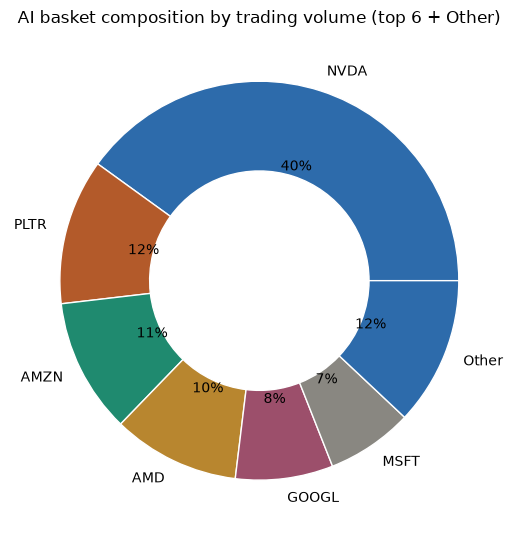

In [13]:
TOP_N_PIE = 6
pie_shares = vol_share.head(TOP_N_PIE).copy()
other_total = vol_share.iloc[TOP_N_PIE:].sum()
if other_total > 0:
    pie_shares['Other'] = round(other_total, 1)

palette = ['#2d6bab', '#b35a2a', '#1f8a6f', '#b8862f', '#9c4f6b', '#357a2b']
colors = palette[:len(pie_shares)]
if 'Other' in pie_shares.index:
    colors[-1] = '#898781'  # muted gray for Other, matches the live dashboard's donut

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(pie_shares, labels=pie_shares.index, autopct='%1.0f%%', colors=colors,
       wedgeprops={'width': 0.45, 'edgecolor': 'white'})
ax.set_title('AI basket composition by trading volume (top 6 + Other)')
plt.tight_layout()
plt.show()

In [14]:
top_symbol, top_share = vol_share.index[0], vol_share.iloc[0]
second_symbol, second_share = vol_share.index[1], vol_share.iloc[1]
rest_share = 100 - top_share
scale_vs_second = top_share / second_share
basket_size = len(vol_share)
comparison = (
    "more than the rest of the basket combined"
    if top_share > rest_share else
    f"nearly as much as the rest of the basket combined ({rest_share:.0f}%)"
)

display(Markdown(
    f"**Key finding:** {top_symbol} accounts for {top_share:.0f}% of the AI basket's combined trading volume, "
    f"{comparison}, and {scale_vs_second:.1f}x {second_symbol}, the next-largest contributor at {second_share:.0f}%. "
    f"A basket spanning {basket_size} names still behaves, in trading-activity terms, like a concentrated "
    f"position in {top_symbol} with satellite names attached."
))

**Key finding:** NVDA accounts for 40% of the AI basket's combined trading volume, nearly as much as the rest of the basket combined (60%), and 3.4x PLTR, the next-largest contributor at 12%. A basket spanning 11 names still behaves, in trading-activity terms, like a concentrated position in NVDA with satellite names attached.

In [15]:
display(Markdown(
    f"**Insight:** Anyone marketing or evaluating this basket as diversified AI exposure should treat that claim "
    f"skeptically, since {top_symbol} alone is doing most of the work. In practical terms, the basket's risk profile "
    f"is closer to a concentrated {top_symbol} position than to a spread bet across the AI theme, so company-specific "
    f"news about {top_symbol} such as an earnings miss, a competitive threat, or a regulatory change should be "
    f"treated as a risk to the whole basket rather than to just one holding among several."
))

**Insight:** Anyone marketing or evaluating this basket as diversified AI exposure should treat that claim skeptically, since NVDA alone is doing most of the work. In practical terms, the basket's risk profile is closer to a concentrated NVDA position than to a spread bet across the AI theme, so company-specific news about NVDA such as an earnings miss, a competitive threat, or a regulatory change should be treated as a risk to the whole basket rather than to just one holding among several.

## 4. Sector return sensitivity to interest-rate moves

Splits trading days into "10Y yield rose" vs. "10Y yield fell," then compounds each sector's return within each group. Growth-tilted sectors are expected to underperform on rising-rate days; this checks whether that holds and whether any sector breaks the pattern.

In [16]:
yield_10y = macro[macro['series'] == '10y_yield'].sort_values('date').reset_index(drop=True)
yield_10y['direction'] = yield_10y['value'].diff().apply(lambda d: 'rising' if d > 0 else ('falling' if d < 0 else None))
direction_by_date = yield_10y.set_index('date')['direction'].to_dict()

sector_labeled = sector.dropna(subset=['daily_return']).copy()
sector_labeled['yield_direction'] = sector_labeled['date'].map(direction_by_date)
sector_labeled = sector_labeled.dropna(subset=['yield_direction'])

def compound(returns):
    return ((1 + returns).prod() - 1) * 100

rate_sensitivity = (
    sector_labeled.groupby(['symbol', 'yield_direction'])['daily_return']
    .apply(compound)
    .unstack('yield_direction')
    .round(2)
    .sort_values('rising')
)
rate_sensitivity

yield_direction,falling,rising
symbol,,
XLY,36.92,-37.21
XLC,24.23,-26.13
XLB,47.83,-25.22
XLRE,38.93,-20.08
XLI,45.02,-18.38
XLV,40.47,-10.45
XLU,26.34,-9.05
XLP,15.65,-8.71
XLK,29.94,-8.22


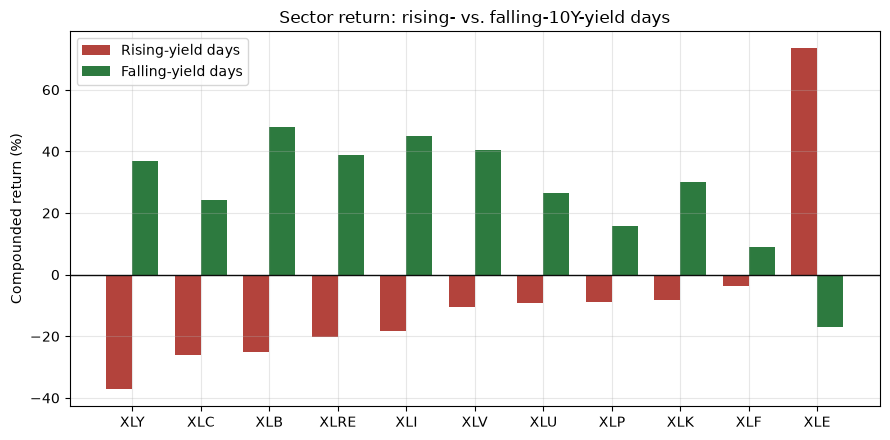

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(rate_sensitivity))
width = 0.38
ax.bar(x - width/2, rate_sensitivity['rising'], width, label='Rising-yield days', color='#b3433c')
ax.bar(x + width/2, rate_sensitivity['falling'], width, label='Falling-yield days', color='#2d7a3f')
ax.axhline(0, color='#0b0b0b', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(rate_sensitivity.index)
ax.set_ylabel('Compounded return (%)')
ax.set_title('Sector return: rising- vs. falling-10Y-yield days')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
exceptions = rate_sensitivity[rate_sensitivity['rising'] > rate_sensitivity['falling']]
typical_count = len(rate_sensitivity) - len(exceptions)

if len(exceptions) > 0:
    exc_names = ", ".join(exceptions.index)
    exception_line = (
        f"{exc_names} moved the opposite way, gaining rather than falling when yields rose, "
        f"a sector-specific story rather than a broad rate story."
    )
else:
    exception_line = "No sector broke the pattern over this window."

display(Markdown(
    f"**Key finding:** {typical_count} of {len(rate_sensitivity)} sectors followed the expected growth-sensitivity "
    f"pattern, falling on rising-yield days and rallying on falling-yield days. {exception_line}"
))

**Key finding:** 10 of 11 sectors followed the expected growth-sensitivity pattern, falling on rising-yield days and rallying on falling-yield days. XLE moved the opposite way, gaining rather than falling when yields rose, a sector-specific story rather than a broad rate story.

In [19]:
if len(exceptions) > 0:
    insight_text = (
        f"This split is directly usable for positioning ahead of a known rate event such as an FOMC meeting: if "
        f"yields are expected to rise, the data supports rotating away from growth-tilted sectors and toward "
        f"{exc_names} specifically as a hedge, rather than moving to cash. It also doubles as an attribution check: "
        f"if a growth sector rallies on a day yields are rising, something sector-specific is driving it, worth "
        f"flagging rather than folding into the usual rate narrative."
    )
else:
    insight_text = (
        "This split is directly usable for positioning ahead of a known rate event such as an FOMC meeting: if "
        "yields are expected to rise, the data supports rotating away from growth-tilted sectors broadly, since no "
        "sector in this window offered a clean hedge against that move."
    )

display(Markdown(f"**Insight:** {insight_text}"))

**Insight:** This split is directly usable for positioning ahead of a known rate event such as an FOMC meeting: if yields are expected to rise, the data supports rotating away from growth-tilted sectors and toward XLE specifically as a hedge, rather than moving to cash. It also doubles as an attribution check: if a growth sector rallies on a day yields are rising, something sector-specific is driving it, worth flagging rather than folding into the usual rate narrative.

## 5. Realized volatility trend

Rolling 20-day realized volatility of the S&P 500 across the full history, with the highest- and lowest-volatility readings called out.

In [20]:
vol = volatility.dropna(subset=['rolling_20d_volatility']).sort_values('date').reset_index(drop=True)
vol_max = vol.loc[vol['rolling_20d_volatility'].idxmax()]
vol_min = vol.loc[vol['rolling_20d_volatility'].idxmin()]

print(f"Earliest reading: {vol['date'].iloc[0]}  {vol['rolling_20d_volatility'].iloc[0]*100:.2f}%")
print(f"Latest reading:   {vol['date'].iloc[-1]}  {vol['rolling_20d_volatility'].iloc[-1]*100:.2f}%")
print(f"Highest: {vol_max['date']}  {vol_max['rolling_20d_volatility']*100:.2f}%")
print(f"Lowest:  {vol_min['date']}  {vol_min['rolling_20d_volatility']*100:.2f}%")

Earliest reading: 2025-08-19  0.68%
Latest reading:   2026-07-28  0.60%
Highest: 2026-04-09  1.29%
Lowest:  2025-10-03  0.37%


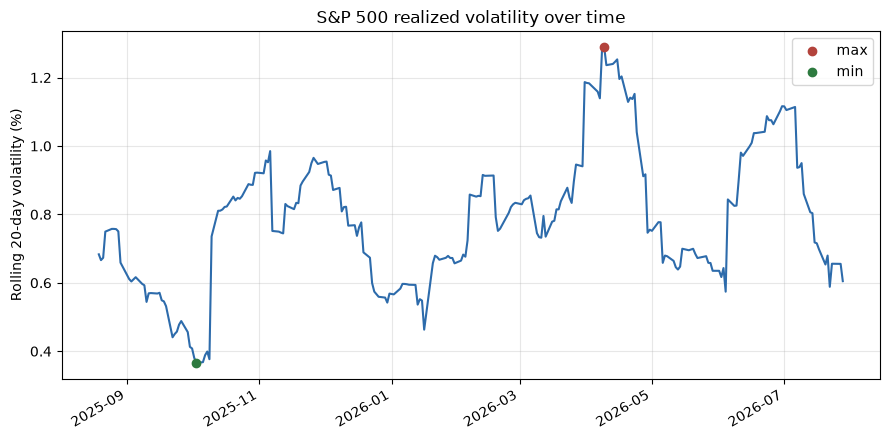

In [21]:
fig, ax = plt.subplots(figsize=(9, 4.5))
dates = pd.to_datetime(vol['date'])
ax.plot(dates, vol['rolling_20d_volatility']*100, color='#2d6bab', linewidth=1.5)
ax.scatter([pd.to_datetime(vol_max['date'])], [vol_max['rolling_20d_volatility']*100], color='#b3433c', zorder=5, label='max')
ax.scatter([pd.to_datetime(vol_min['date'])], [vol_min['rolling_20d_volatility']*100], color='#2d7a3f', zorder=5, label='min')
ax.set_ylabel('Rolling 20-day volatility (%)')
ax.set_title('S&P 500 realized volatility over time')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [22]:
avg_vol = vol['rolling_20d_volatility'].mean()
spike_ratio = vol_max['rolling_20d_volatility'] / avg_vol

display(Markdown(
    f"**Key finding:** realized volatility peaked at {vol_max['rolling_20d_volatility']*100:.1f}% on {vol_max['date']}, "
    f"about {spike_ratio:.1f}x the {avg_vol*100:.2f}% trailing-window average, and has since eased back to "
    f"{vol['rolling_20d_volatility'].iloc[-1]*100:.2f}% as of the latest reading. That window is the clearest stress "
    f"signal in the data and the first place to look for a market-moving catalyst around {vol_max['date']}."
))

**Key finding:** realized volatility peaked at 1.3% on 2026-04-09, about 1.6x the 0.78% trailing-window average, and has since eased back to 0.60% as of the latest reading. That window is the clearest stress signal in the data and the first place to look for a market-moving catalyst around 2026-04-09.

In [23]:
display(Markdown(
    f"**Insight:** For a risk manager, the practical value here is the lead it gives for further investigation. "
    f"Cross-referencing {vol_max['date']} against news and earnings calendars turns 'volatility spiked' into a "
    f"specific cause, and knowing the cause is what determines whether it was a one-off shock or a recurring pattern, "
    f"such as an earnings season or a scheduled macro release, worth sizing positions around in advance next time."
))

**Insight:** For a risk manager, the practical value here is the lead it gives for further investigation. Cross-referencing 2026-04-09 against news and earnings calendars turns 'volatility spiked' into a specific cause, and knowing the cause is what determines whether it was a one-off shock or a recurring pattern, such as an earnings season or a scheduled macro release, worth sizing positions around in advance next time.

## Summary

| # | Finding | Confidence |
|---|---|---|
| 1 | AI basket outperformed the S&P 500 over the full period | High: direct calculation |
| 2 | Attention spikes vs. stock moves | Mixed: no day-to-day relationship; a suggestive but small-sample pattern around the biggest spikes only |
| 3 | AI basket trading volume is concentrated in one name | High: direct calculation |
| 4 | Growth sectors underperform on rising-yield days, Energy is the exception | High: consistent with known rate-sensitivity dynamics |
| 5 | Volatility had one clear outlier window | High: direct calculation |

Re-run this notebook top to bottom each month (`Kernel -> Restart & Run All`) to refresh every number and chart against the latest accumulated data. Section 2 in particular is worth re-checking regularly: the event-study sample grows with every new attention spike, so its conclusion may firm up or fall apart as more data arrives.